In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
import os
from tqdm import tqdm
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# XGBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
# LightGBM
from lightgbm import LGBMRegressor
# CatBoost
from catboost import CatBoostRegressor
# Gradient Boosting from scikit-learn
from sklearn.ensemble import GradientBoostingRegressor
# AdaBoost Regressor
from sklearn.ensemble import AdaBoostRegressor
pd.set_option("display.max_columns",None)
%matplotlib inline

In [2]:
df=pd.read_csv("/kaggle/input/predicting-the-price-of-diamond/train.csv")

In [3]:
df.drop(columns=["id"],axis=1,inplace=True)

In [4]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.31,Ideal,H,VS2,61.8,57.0,4.39,4.36,2.68,681.0
1,0.38,Ideal,G,VVS1,60.8,56.0,4.67,4.73,2.89,1132.0
2,0.38,Very Good,G,SI1,61.0,56.0,4.68,4.64,2.81,1307.0
3,0.71,Premium,H,SI1,60.6,58.0,5.83,5.80,3.49,1308.0
4,0.31,Very Good,G,IF,62.0,57.0,4.32,4.36,2.70,645.0


In [5]:
df["cut"] = df["cut"].apply(lambda x: x if x in ["Ideal", "Premium", "Very Good"] else "Very Good")

In [6]:
df["cut"].value_counts()

cut
Ideal        9408
Premium      5554
Very Good    5038
Name: count, dtype: int64

In [7]:
top_colors = ["G", "E", "F", "H", "D"]
df["color"] = df["color"].apply(lambda x: x if x in top_colors else "D")

In [8]:
df["color"].value_counts()

color
D    4881
G    4583
E    3676
F    3657
H    3203
Name: count, dtype: int64

In [9]:
top_clarity = ["SI1", "VS2", "SI2", "VS1", "VVS2"]

# Combine the rest into "VS1" (last of top 5)
df["clarity"] = df["clarity"].apply(lambda x: x if x in top_clarity else "VVS2")

In [10]:
df["clarity"].value_counts()

clarity
SI1     5588
VS2     5094
SI2     3457
VVS2    3092
VS1     2769
Name: count, dtype: int64

In [11]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.31,Ideal,H,VS2,61.8,57.0,4.39,4.36,2.68,681.0
1,0.38,Ideal,G,VVS2,60.8,56.0,4.67,4.73,2.89,1132.0
2,0.38,Very Good,G,SI1,61.0,56.0,4.68,4.64,2.81,1307.0
3,0.71,Premium,H,SI1,60.6,58.0,5.83,5.80,3.49,1308.0
4,0.31,Very Good,G,VVS2,62.0,57.0,4.32,4.36,2.70,645.0


In [12]:
X = df.drop(columns=["price"])
y = df["price"]

In [13]:
numeric = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat = X.select_dtypes(include=["object"]).columns.tolist()

scaler = MinMaxScaler()
X[numeric] = scaler.fit_transform(X[numeric])

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat] = ordinal_encoder.fit_transform(X[cat])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
model_final = CatBoostRegressor(iterations=1000, learning_rate=0.005, depth=6, random_state=42, verbose=500)
model_final.fit(X_train, y_train)

0:	learn: 3999.2789475	total: 51.2ms	remaining: 51.2s
500:	learn: 2341.1799319	total: 1.46s	remaining: 1.46s
999:	learn: 2303.1553119	total: 2.83s	remaining: 0us


In [16]:
y_test_pred = model_final.predict(X_test)
print("\nTest Set Metrics:")
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


Test Set Metrics:
R2: 0.6504212306372796
MAE: 1385.7296006746187
MSE: 5690951.705881901
RMSE: 2385.571567964772


In [17]:
test_df=pd.read_csv("/kaggle/input/predicting-the-price-of-diamond/test.csv")

In [18]:
test_df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z
0,20000,0.51,Very Good,E,VS1,62.8,57.0,5.06,5.07,3.16
1,20001,0.90,Very Good,D,VS2,63.6,61.0,6.04,6.01,3.86
2,20002,0.33,Ideal,D,VS2,62.3,55.0,4.42,4.46,2.75
3,20003,0.32,Very Good,F,VS1,63.4,56.0,4.42,4.45,2.78
4,20004,0.30,Ideal,I,SI1,63.0,55.0,4.33,4.30,2.70


In [19]:
test_df.shape

(30000, 10)

In [20]:
test_df["cut"] = test_df["cut"].apply(lambda x: x if x in ["Ideal", "Premium", "Very Good"] else "Very Good")
top_colors = ["G", "E", "F", "H", "D"]
test_df["color"] = test_df["color"].apply(lambda x: x if x in top_colors else "D")
top_clarity = ["SI1", "VS2", "SI2", "VS1", "VVS2"]
test_df["clarity"] = test_df["clarity"].apply(lambda x: x if x in top_clarity else "VVS2")

In [21]:
X_test_copy = test_df.drop(columns=["id"]).copy()
X_test_copy[numeric] = scaler.transform(X_test_copy[numeric])
X_test_copy[cat] = ordinal_encoder.transform(X_test_copy[cat])

In [22]:
predictions = model_final.predict(X_test_copy)
submission = pd.DataFrame({"id": test_df["id"], "price": predictions})
submission.to_csv("submission.csv", index=False)
print("✅ Submission file created")

✅ Submission file created


# Model 2

In [23]:
df=pd.read_csv("/kaggle/input/predicting-the-price-of-diamond/train.csv")

In [24]:
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,0.31,Ideal,H,VS2,61.8,57.0,4.39,4.36,2.68,681.0
1,1,0.38,Ideal,G,VVS1,60.8,56.0,4.67,4.73,2.89,1132.0
2,2,0.38,Very Good,G,SI1,61.0,56.0,4.68,4.64,2.81,1307.0
3,3,0.71,Premium,H,SI1,60.6,58.0,5.83,5.80,3.49,1308.0
4,4,0.31,Very Good,G,IF,62.0,57.0,4.32,4.36,2.70,645.0


In [25]:
df.drop(columns=["id"],axis=1,inplace=True)

In [26]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [27]:
df["cut"].value_counts()

cut
Ideal        9408
Premium      5554
Very Good    3790
Good         1081
Fair          166
D               1
Name: count, dtype: int64

In [28]:
df["color"].value_counts()

color
G    4583
E    3676
F    3657
H    3203
D    2480
I    1704
J     697
Name: count, dtype: int64

In [29]:
df["clarity"].value_counts()

clarity
SI1     5588
VS2     5094
SI2     3457
VS1     2769
VVS2    1591
VVS1    1046
IF       396
I1        59
Name: count, dtype: int64

In [30]:
df = df[df['cut'] != 'D']

In [31]:
valid_cuts = ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
valid_colors = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
valid_clarities = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']
df = df[df['cut'].isin(valid_cuts) & df['color'].isin(valid_colors) & df['clarity'].isin(valid_clarities)]

In [32]:
for col in ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[col] = df[col].clip(lower_bound, upper_bound)

In [33]:
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_map = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

df['cut'] = df['cut'].map(cut_map)
df['color'] = df['color'].map(color_map)
df['clarity'] = df['clarity'].map(clarity_map)

# Frequency encoding
cut_freq = df['cut'].value_counts(normalize=True)
color_freq = df['color'].value_counts(normalize=True)
clarity_freq = df['clarity'].value_counts(normalize=True)
df['cut_freq'] = df['cut'].map(cut_freq)
df['color_freq'] = df['color'].map(color_freq)
df['clarity_freq'] = df['clarity'].map(clarity_freq)


# Interaction features
df['cut_clarity'] = df['cut'] * df['clarity']
df['cut_color'] = df['cut'] * df['color']
df['color_clarity'] = df['color'] * df['clarity']

# Step 3: Numerical Feature Transformations
# Volume (handle zero values)
df['volume'] = df['x'] * df['y'] * df['z']
df['volume'] = df['volume'].replace(0, df['volume'].median())

# Ratios
df['depth_to_table'] = df['depth'] / df['table'].replace(0, df['table'].median())
df['carat_per_volume'] = df['carat'] / df['volume']
df['xy_ratio'] = df['x'] / df['y'].replace(0, df['y'].median())

# Shape approximation
df['is_round'] = (df['xy_ratio'].between(0.95, 1.05)).astype(int)

# Polynomial features
df['carat_squared'] = df['carat'] ** 2
df['volume_squared'] = df['volume'] ** 2
df['depth_squared'] = df['depth'] ** 2

# Log transformation
df['log_carat'] = np.log1p(df['carat'])

In [34]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price,cut_freq,color_freq,clarity_freq,cut_clarity,cut_color,color_clarity,volume,depth_to_table,carat_per_volume,xy_ratio,is_round,carat_squared,volume_squared,depth_squared,log_carat
0,0.31,5,3,4,61.8,57.0,4.39,4.36,2.68,681.0,0.470424,0.160158,0.254713,20,15,12,51.296272,1.084211,0.006043,1.006881,1,0.0961,2631.307521,3819.24,0.270027
1,0.38,5,4,7,60.8,56.0,4.67,4.73,2.89,1132.0,0.470424,0.229161,0.052303,35,20,28,63.837499,1.085714,0.005953,0.987315,1,0.1444,4075.226279,3696.64,0.322083
2,0.38,3,4,3,61.0,56.0,4.68,4.64,2.81,1307.0,0.189509,0.229161,0.279364,9,12,12,61.019712,1.089286,0.006227,1.008621,1,0.1444,3723.405253,3721.00,0.322083
3,0.71,4,3,3,60.6,58.0,5.83,5.80,3.49,1308.0,0.277714,0.160158,0.279364,12,12,9,118.010860,1.044828,0.006016,1.005172,1,0.5041,13926.563078,3672.36,0.536493
4,0.31,3,4,8,62.0,57.0,4.32,4.36,2.70,645.0,0.189509,0.229161,0.019801,24,12,32,50.855040,1.087719,0.006096,0.990826,1,0.0961,2586.235093,3844.00,0.270027


In [35]:
df.shape

(19999, 25)

In [36]:
# Define numerical and categorical columns
numerical_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price', 'cut_freq', 'color_freq', 
                  'clarity_freq', 'volume', 'depth_to_table', 'carat_per_volume', 'xy_ratio', 
                  'carat_squared', 'volume_squared', 'depth_squared', 'log_carat']
categorical_cols = ['cut', 'color', 'clarity', 'cut_clarity', 'cut_color', 'color_clarity', 'is_round']

# Filter columns to ensure they exist in the dataset
numerical_cols = [col for col in numerical_cols if col in df.columns]
categorical_cols = [col for col in categorical_cols if col in df.columns]

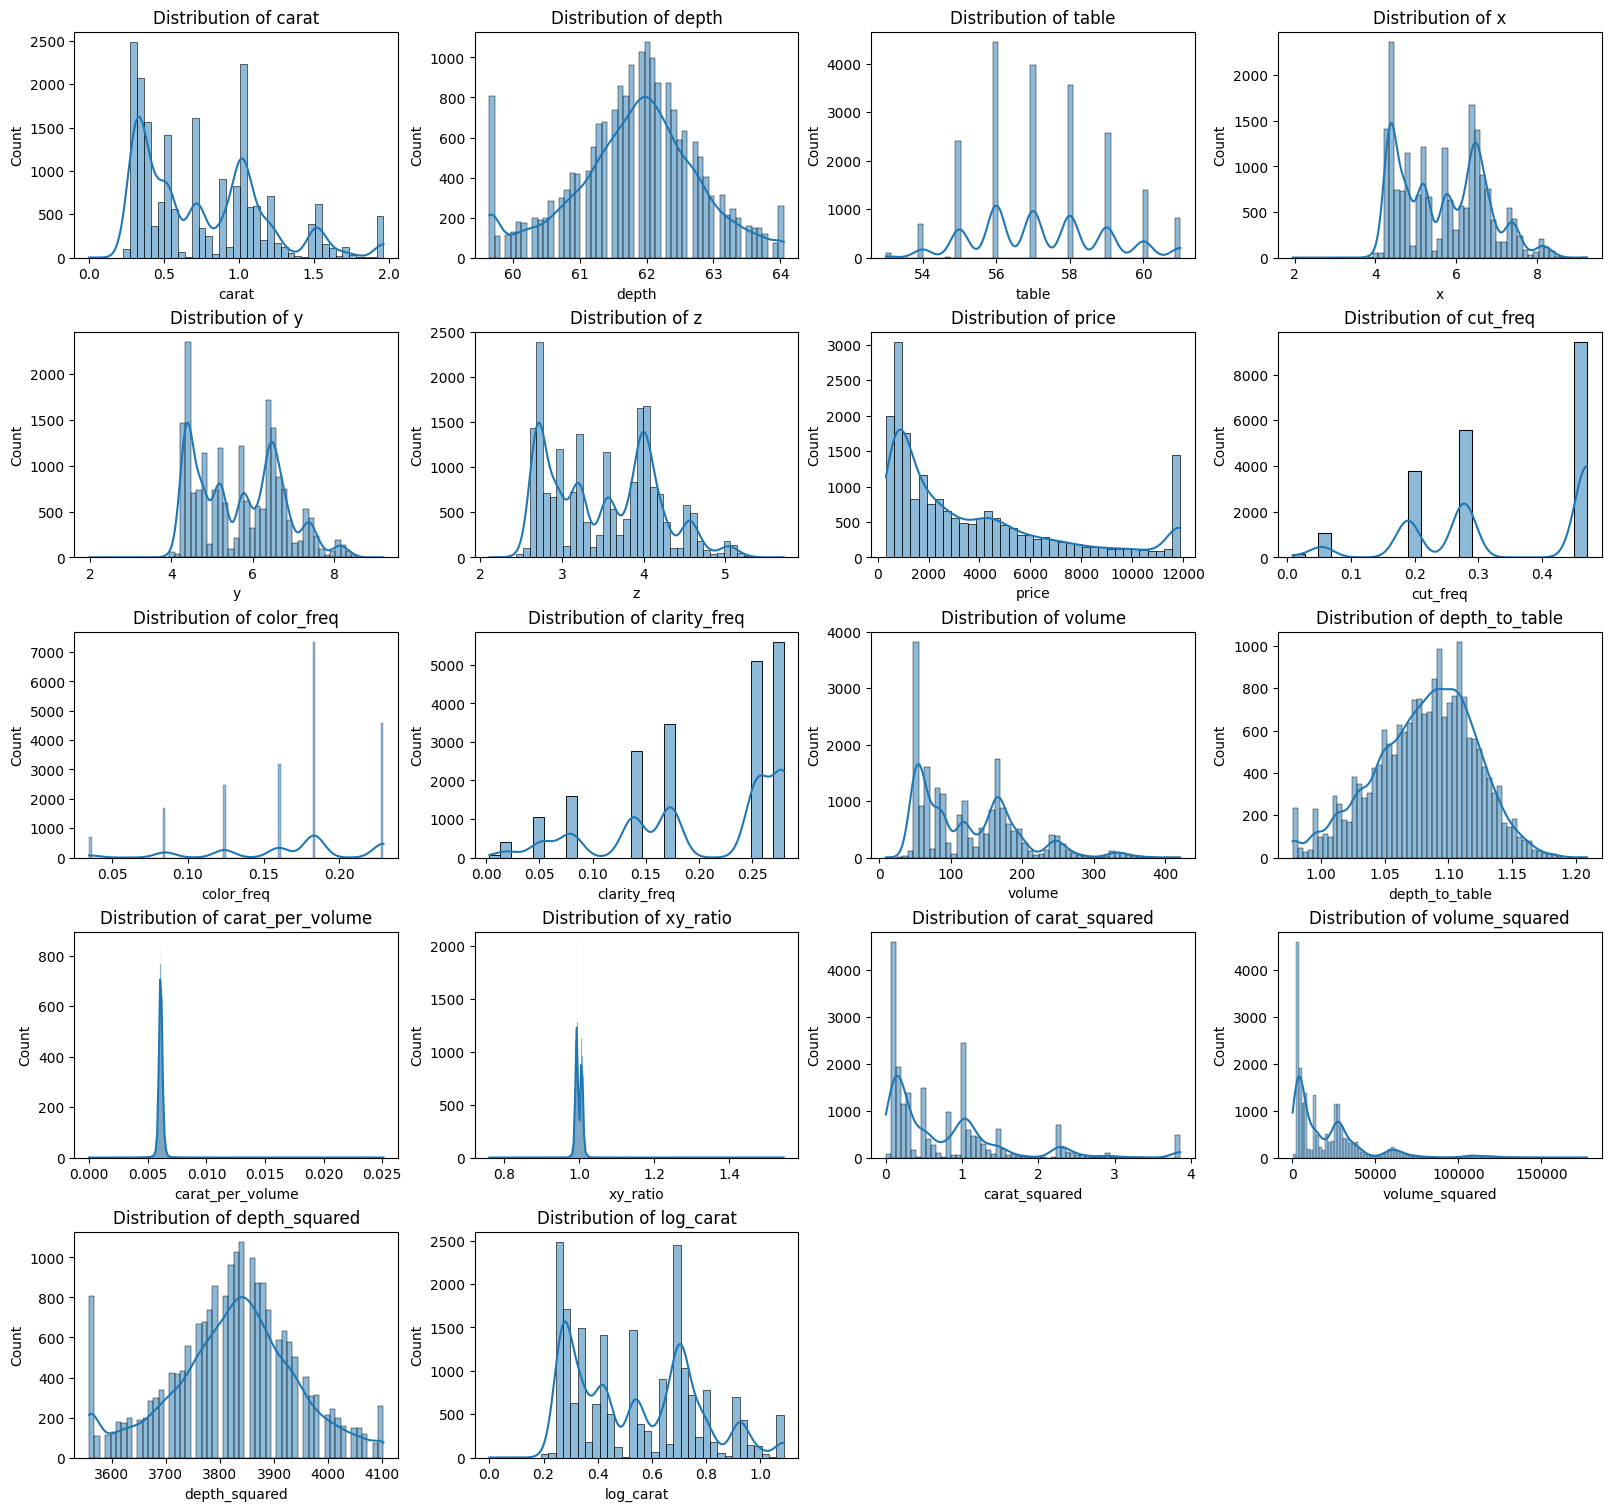

In [37]:
n_cols = 4  # Number of columns in subplot grid
n_rows = int(np.ceil(len(numerical_cols) / n_cols))  # Calculate rows needed
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3), constrained_layout=True)
axes = axes.flatten()  # Flatten for easier indexing

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()


Plotting Count Plots for Categorical Features...


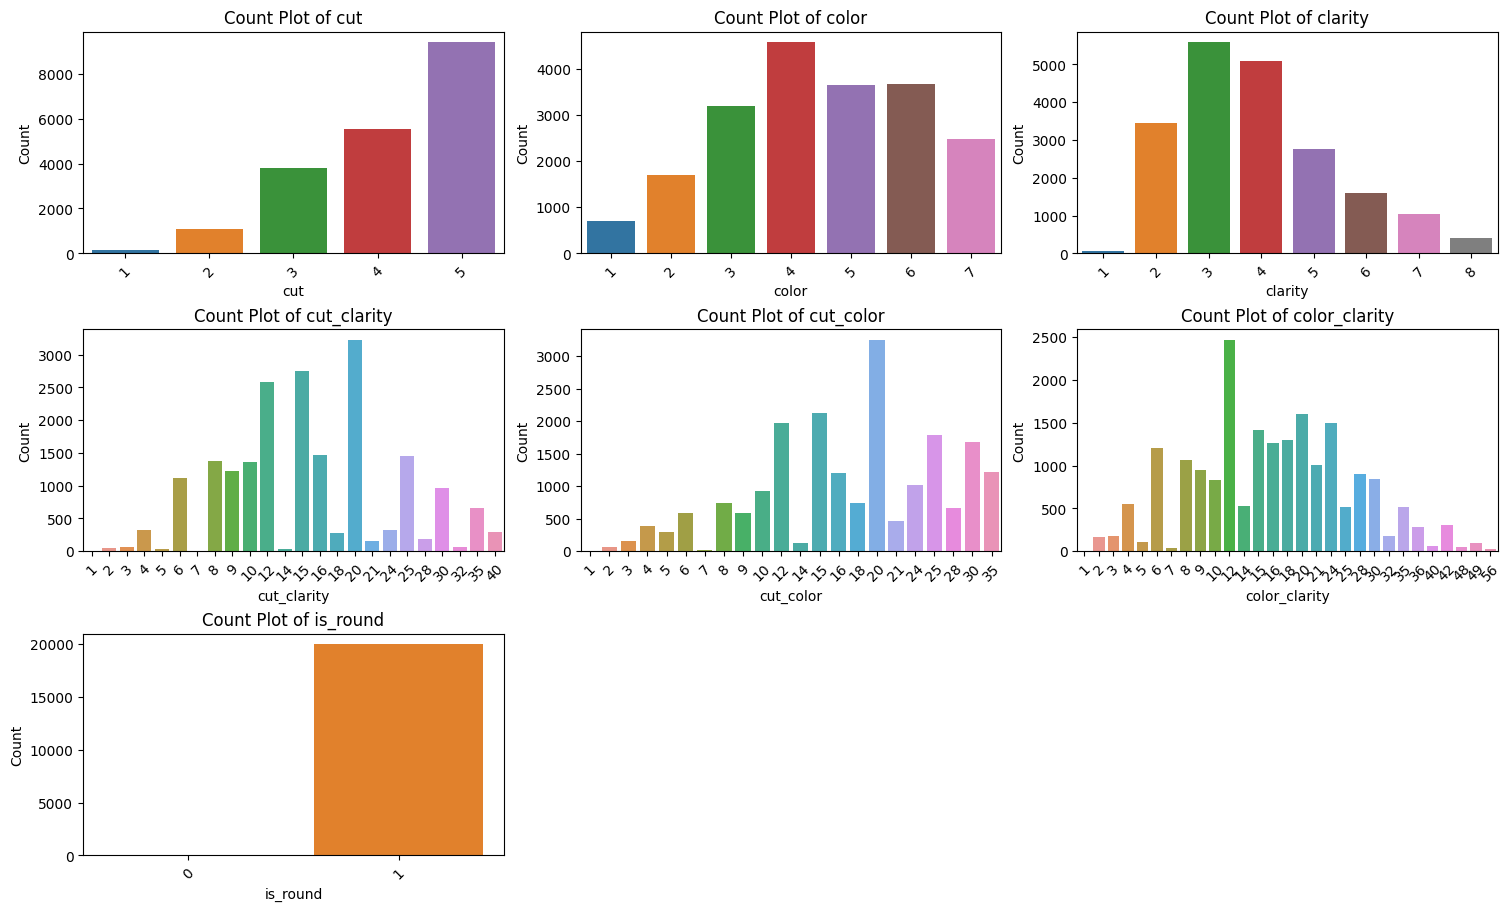

In [38]:
print("\nPlotting Count Plots for Categorical Features...")
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.show()


Plotting Scatter Plots vs Price...


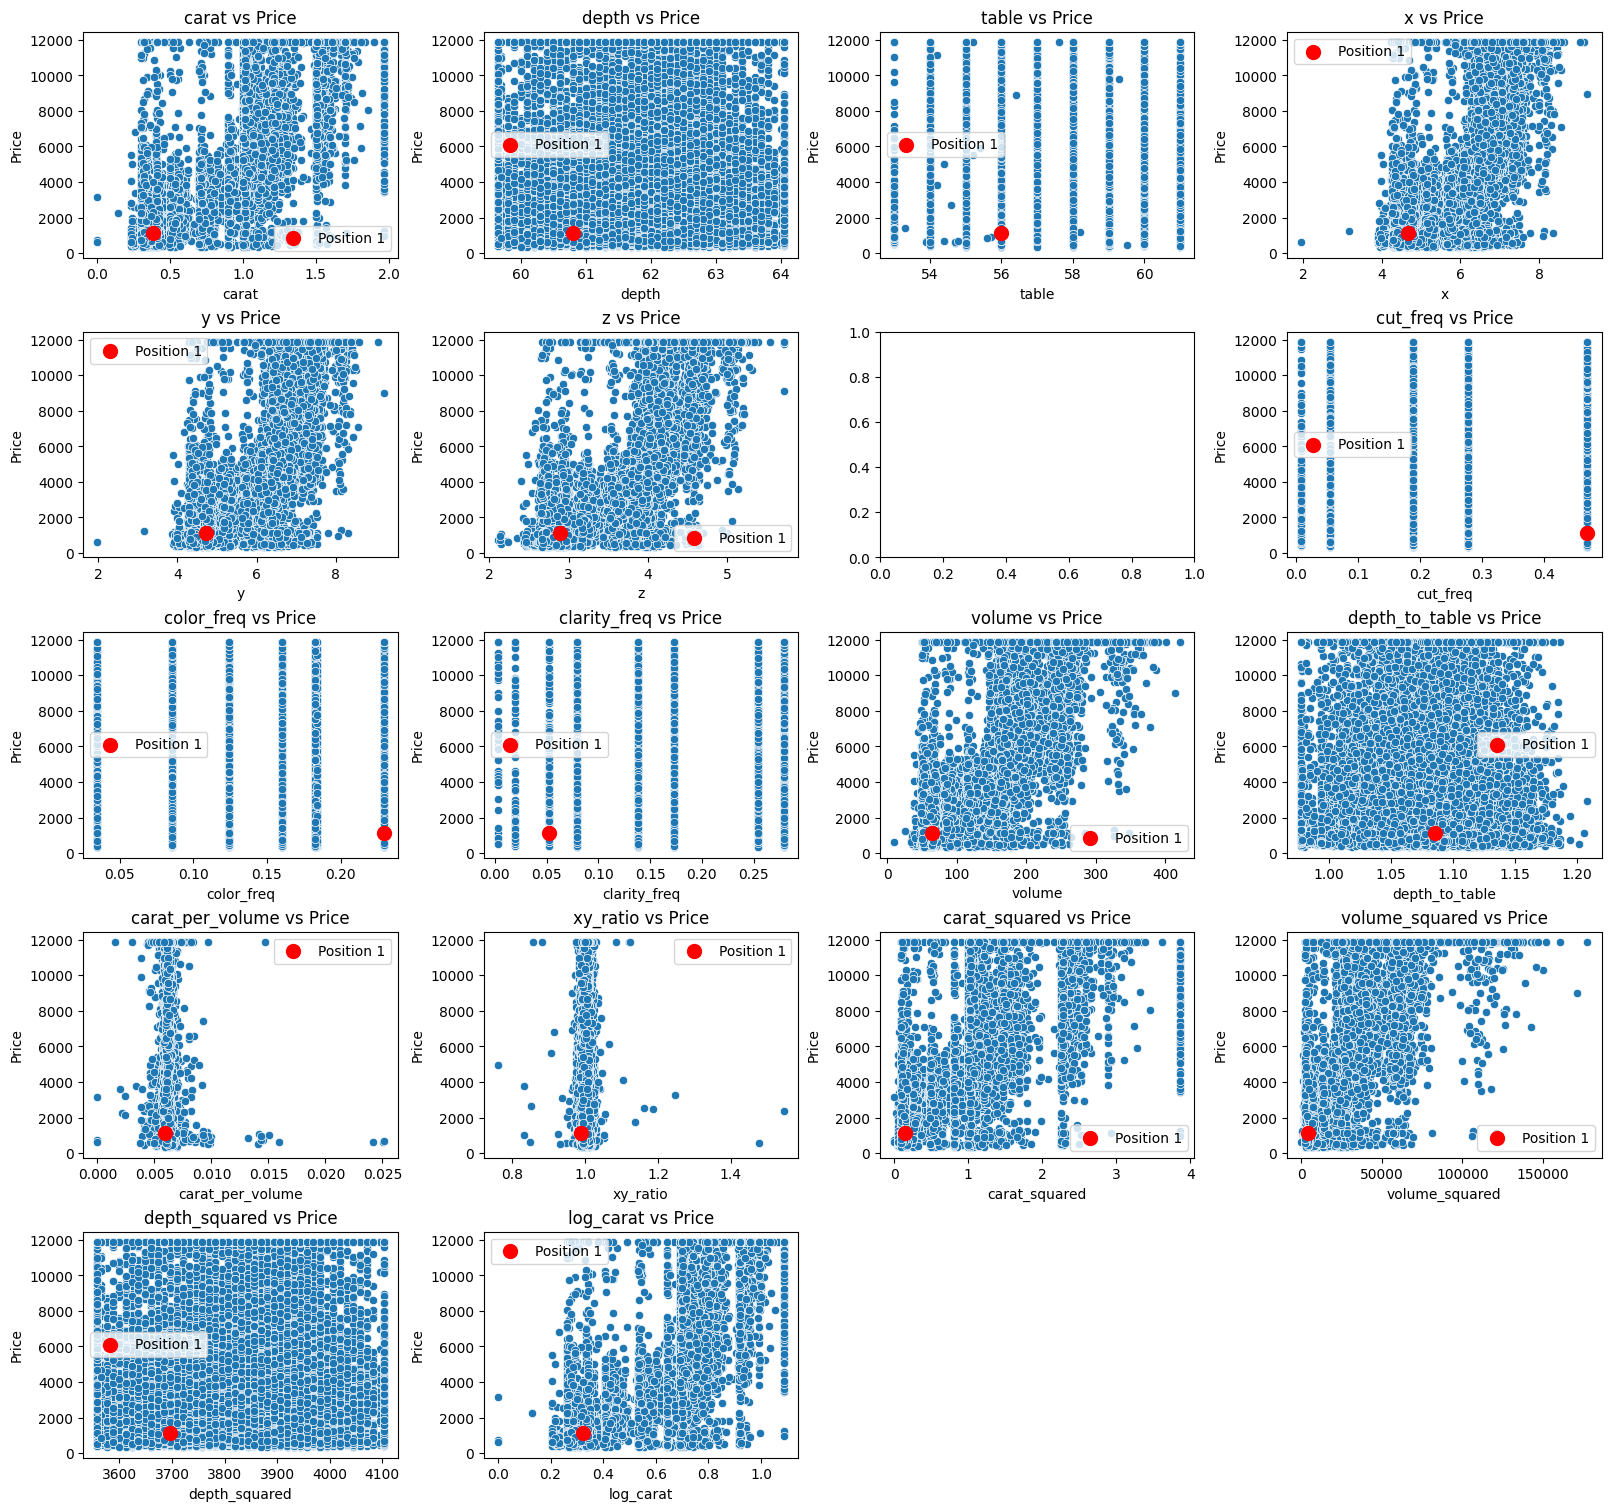

In [39]:
print("\nPlotting Scatter Plots vs Price...")
n_cols = 4
n_rows = int(np.ceil((len(numerical_cols) - 1) / n_cols))  # Exclude 'price'
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if col != 'price':
        sns.scatterplot(x=col, y='price', data=df, ax=axes[i])
        # Highlight position 1
        axes[i].scatter(df.iloc[1][col], df.iloc[1]['price'], color='red', s=100, label='Position 1')
        axes[i].set_title(f'{col} vs Price')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Price')
        axes[i].legend()

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()


Plotting Box Plots for Categorical Features vs Price...


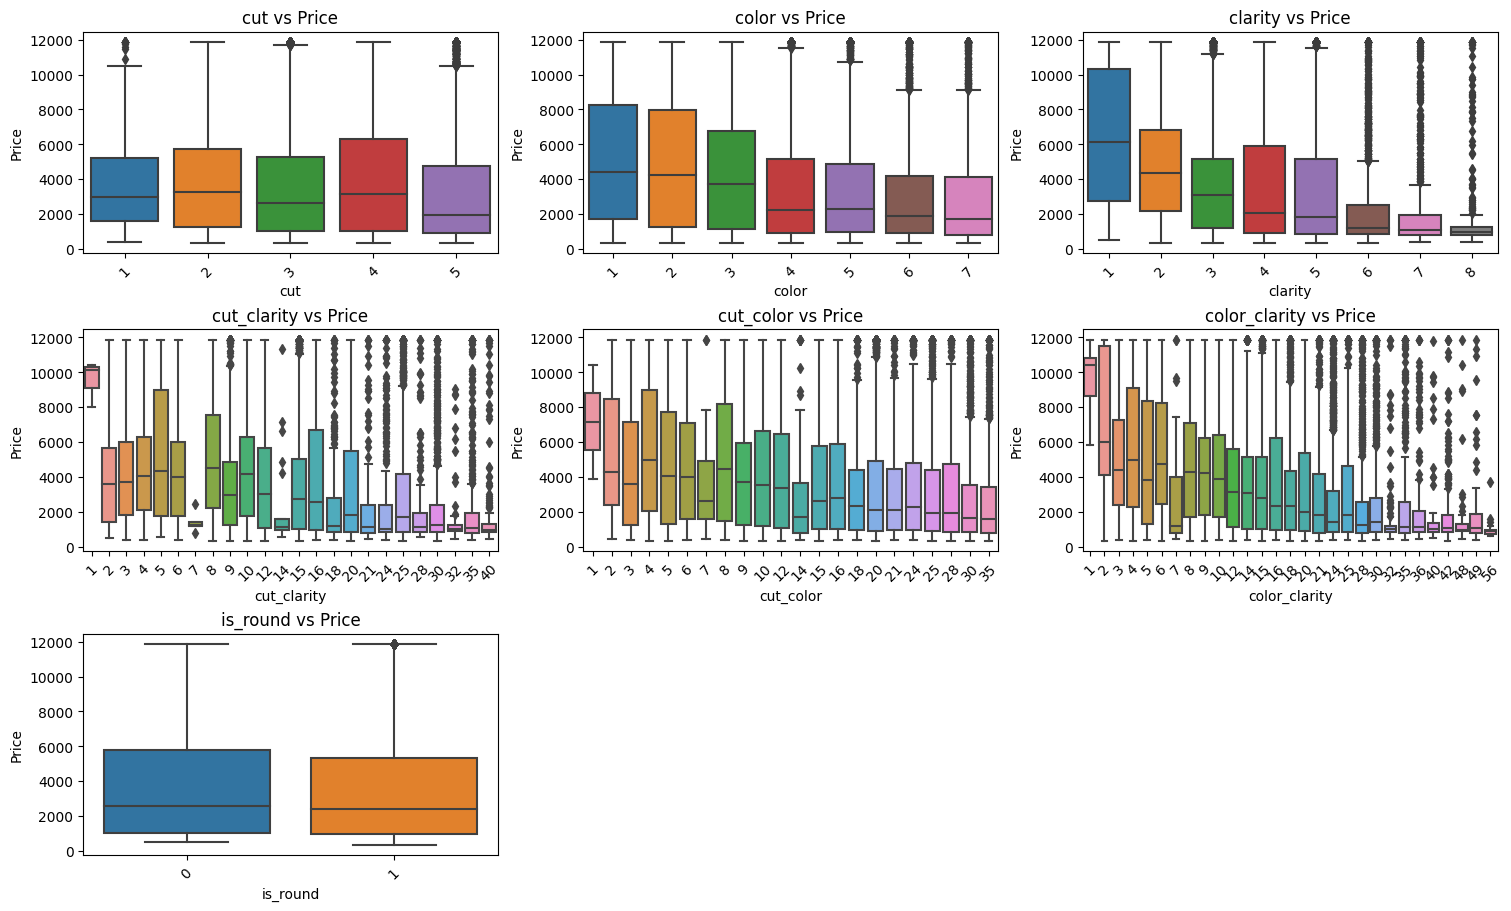

In [40]:
print("\nPlotting Box Plots for Categorical Features vs Price...")
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(x=col, y='price', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.savefig('/kaggle/working/box_price.png')
plt.show()


Plotting Correlation Heatmap...


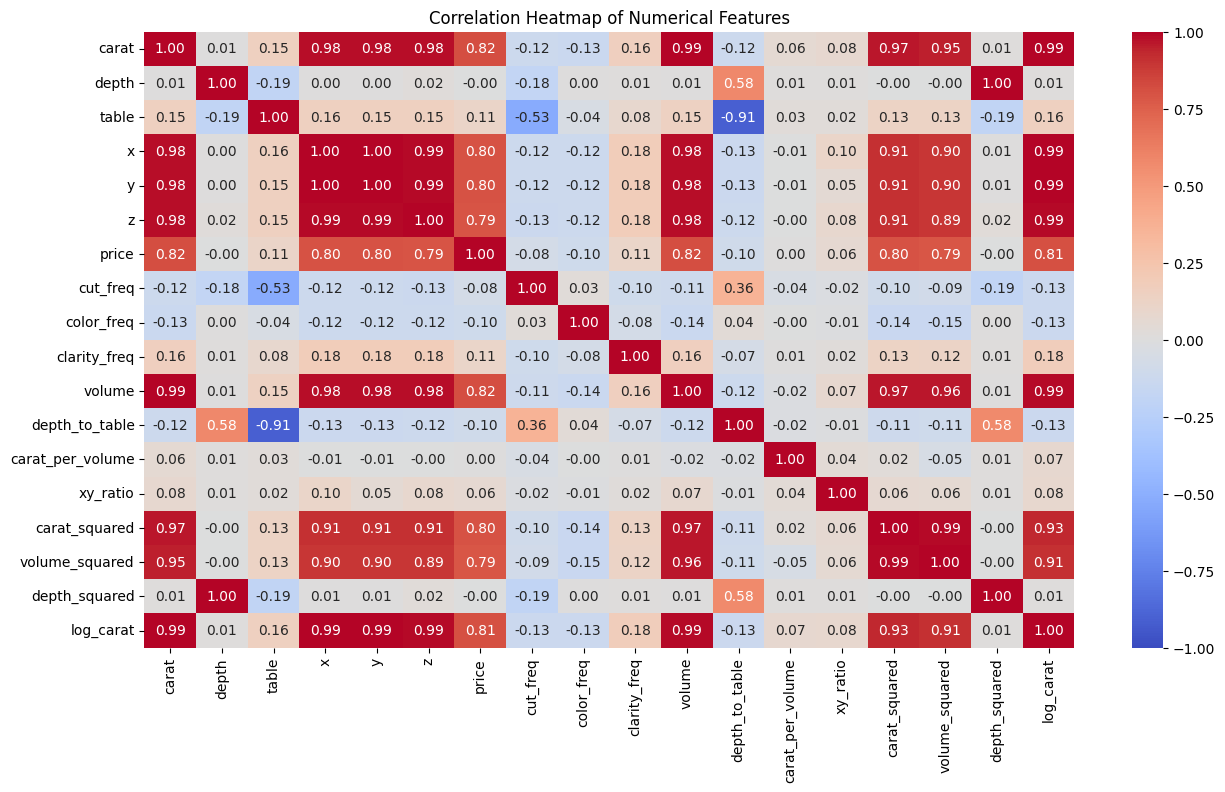

In [41]:
print("\nPlotting Correlation Heatmap...")
plt.figure(figsize=(15, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [42]:
scaler = StandardScaler()
continuous_features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'depth_to_table', 
                       'carat_per_volume', 'xy_ratio', 'log_carat', 'carat_squared', 
                       'volume_squared', 'depth_squared']
df[continuous_features] = scaler.fit_transform(df[continuous_features])

In [43]:
X = df.drop(['price'], axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
import xgboost as xgb
model = CatBoostRegressor(iterations=1000,learning_rate=0.005,depth=6,random_seed=42,verbose=300)

model.fit(X_train, y_train)

0:	learn: 3420.7766243	total: 6.28ms	remaining: 6.27s
300:	learn: 2024.9675544	total: 1.19s	remaining: 2.77s
600:	learn: 1902.0248044	total: 2.35s	remaining: 1.56s
900:	learn: 1884.4941937	total: 3.54s	remaining: 389ms
999:	learn: 1880.8484992	total: 3.93s	remaining: 0us


In [45]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R2 Score: {r2:.4f}")


Test RMSE: 1906.5360
Test R2 Score: 0.7013


In [46]:
test_df=pd.read_csv("/kaggle/input/predicting-the-price-of-diamond/test.csv")

In [47]:
test_df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z
0,20000,0.51,Very Good,E,VS1,62.8,57.0,5.06,5.07,3.16
1,20001,0.90,Very Good,D,VS2,63.6,61.0,6.04,6.01,3.86
2,20002,0.33,Ideal,D,VS2,62.3,55.0,4.42,4.46,2.75
3,20003,0.32,Very Good,F,VS1,63.4,56.0,4.42,4.45,2.78
4,20004,0.30,Ideal,I,SI1,63.0,55.0,4.33,4.30,2.70


In [48]:
test_df.shape

(30000, 10)

In [49]:
test_df["cut"].value_counts()

cut
Ideal        14039
Premium       8342
Very Good     5813
Good          1555
Fair           251
Name: count, dtype: int64

In [50]:
test_df["color"].value_counts()

color
G       6897
E       5497
F       5488
H       4743
D       3701
I       2587
J       1085
VVS2       1
SI1        1
Name: count, dtype: int64

In [51]:
test_df["clarity"].value_counts()

clarity
SI1     8332
VS2     7667
SI2     5188
VS1     4129
VVS2    2548
VVS1    1505
IF       543
I1        84
VS3        1
F          1
SI3        1
VVS3       1
Name: count, dtype: int64

In [52]:
valid_cuts = ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
valid_colors = ['D', 'E', 'F', 'G', 'H', 'I', 'J',"VVS2","SI1"]
valid_clarities = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1',"VS3","F","SI3","VVS3"]
test_df = test_df[test_df['cut'].isin(valid_cuts) & test_df['color'].isin(valid_colors) & test_df['clarity'].isin(valid_clarities)]

In [53]:
for col in ['carat', 'depth', 'table', 'x', 'y', 'z']:
    q1, q3 = test_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    test_df[col] = test_df[col].clip(lower_bound, upper_bound)

In [54]:
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7,"VVS2":8,"SI1":9}
clarity_map = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8,"VS3":9,"F":10,
              "SI3":11,"VVS3":12}

In [55]:
test_df['cut'] = test_df['cut'].map(cut_map)
test_df['color'] = test_df['color'].map(color_map)
test_df['clarity'] = test_df['clarity'].map(clarity_map)

In [56]:
cut_freq = test_df['cut'].value_counts(normalize=True)
color_freq = test_df['color'].value_counts(normalize=True)
clarity_freq = test_df['clarity'].value_counts(normalize=True)
test_df['cut_freq'] = test_df['cut'].map(cut_freq)
test_df['color_freq'] = test_df['color'].map(color_freq)
test_df['clarity_freq'] = test_df['clarity'].map(clarity_freq)

test_df['cut_clarity'] = test_df['cut'] * test_df['clarity']
test_df['cut_color'] = test_df['cut'] * test_df['color']
test_df['color_clarity'] = test_df['color'] * test_df['clarity']

In [57]:
test_df['volume'] = test_df['x'] * test_df['y'] * test_df['z']
test_df['volume'] = test_df['volume'].replace(0, test_df['volume'].median())

# Ratios
test_df['depth_to_table'] = test_df['depth'] / test_df['table'].replace(0, test_df['table'].median())
test_df['carat_per_volume'] = test_df['carat'] / test_df['volume']
test_df['xy_ratio'] = test_df['x'] / test_df['y'].replace(0, test_df['y'].median())

# Shape approximation
test_df['is_round'] = (test_df['xy_ratio'].between(0.95, 1.05)).astype(int)

# Polynomial features
test_df['carat_squared'] = test_df['carat'] ** 2
test_df['volume_squared'] = test_df['volume'] ** 2
test_df['depth_squared'] = test_df['depth'] ** 2

# Log transformation
test_df['log_carat'] = np.log1p(test_df['carat'])


In [58]:
test_df[continuous_features] = scaler.transform(test_df[continuous_features])

In [59]:
test_df.shape

(30000, 25)

In [60]:
Id=test_df.id

In [61]:
test_df.drop(columns=["id"],axis=1,inplace=True)

In [62]:
pred=model.predict(test_df)
sub=pd.DataFrame({"id":Id,"price":pred})
sub.to_csv("3rd_submission.csv",index=False)